#### ***Naive Bayes Algorithm***
- ***Naive Bayes is a supervised classification algorithm based on Bayes' Theorem.***

-  ***It predicts the probability of each class and chooses the class with the highest probability. Its key assumption is that features are conditionally independent, which simplifies computation and makes it extremely fast.***

-  ***Gaussian Naive Bayes is used for continuous data, Multinomial for word-count based text classification, and Bernoulli for binary features. It is widely used in spam filtering, sentiment analysis, and document classification because it trains quickly and performs well even on high-dimensional datasets.***

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns

In [2]:
df = pd.read_csv("../data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.shape

(303, 14)

In [4]:
df.count().isnull()

age         False
sex         False
cp          False
trestbps    False
chol        False
fbs         False
restecg     False
thalach     False
exang       False
oldpeak     False
slope       False
ca          False
thal        False
target      False
dtype: bool

In [5]:
x = df.drop("target",axis=1)
y = df["target"]

In [6]:
## Train Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
     x,y,test_size=0.3,random_state=42
)

In [7]:
X_train.shape

(212, 13)

In [8]:
X_test.shape

(91, 13)

In [9]:
# Gaussian Naive (Continous numerical dataset)
from sklearn.naive_bayes import GaussianNB
gnb_model = GaussianNB()
gnb_model.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[ 97.,115.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.46,0.54]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,2.968e-06
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 13)","[[56.59, 0.81, 0.53,..., 1.19, 1.08, 2.58], [52.46, 0.53, 1.43,..., 1.61, 0.27, 2.11]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 13)","[[67.52, 0.15, 0.85,..., 0.32, 1. , 0.39], [90.35, 0.25, 0.89,..., 0.34, 0.51, 0.22]]"


In [13]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix

y_pred = gnb_model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)*100}%")
print(f"Precision Score: {precision_score(y_test,y_pred)*100}%")
print(f"Recall Score: {recall_score(y_test,y_pred)}")

Accuracy Score: 83.51648351648352%
Precision Score: 88.88888888888889%
Recall Score: 0.8


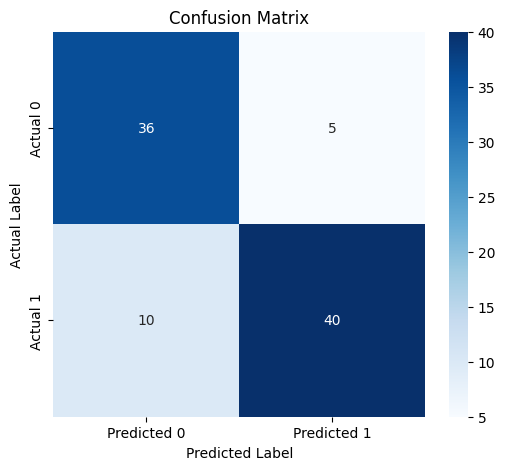

In [14]:
import matplotlib.pylab as plt 

cm = confusion_matrix(y_test, y_pred)
# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,          # Show numbers
    fmt='d',             # Integer format
    cmap='Blues',        # Color theme
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()